##  SHAP Explainability

This notebook illustrates the SHAP explainability layer for the process outcome prediction project.

The notebook explains the final no-leakage Random Forest model from the training pipeline. It does **not** define the training logic itself. It expects the training notebook to provide the trained model, no-leakage test features, feature names, and test labels.

In [1]:
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
from IPython.display import Image, display

from src.explainability.shap_explainer import (
    save_global_shap_summary,
    save_global_shap_importance_table,
    save_selected_local_explanations
)


/Users/so/Desktop/explainable-process-prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Obtain Training Outputs

SHAP requires the final trained Random Forest and the same no-leakage test data used for model evaluation.

Required objects:

- `best_rf`: final Random Forest model trained on no-leakage features
- `X_test_no_leakage`: no-leakage test feature matrix
- `feature_columns_no_leakage`: feature names aligned with `X_test_no_leakage`
- `y_test`: true test labels

In [4]:
import joblib
import pickle

artifact_dir = project_root / "models" / "shap_inputs"

best_rf = joblib.load(artifact_dir / "best_rf.joblib")
X_test_no_leakage = joblib.load(artifact_dir / "X_test_no_leakage.joblib")
y_test = joblib.load(artifact_dir / "y_test.joblib")

with open(artifact_dir / "feature_columns_no_leakage.pkl", "rb") as file:
    feature_columns_no_leakage = pickle.load(file)

In [5]:
required_variables = [
    "best_rf",
    "X_test_no_leakage",
    "feature_columns_no_leakage",
    "y_test",
]

missing_variables = [name for name in required_variables if name not in globals()]


shap_model = best_rf
shap_X = X_test_no_leakage
shap_feature_columns = feature_columns_no_leakage
shap_y_true = y_test
shap_y_pred = shap_model.predict(shap_X)

if shap_X.shape[1] != len(shap_feature_columns):
    raise ValueError(
        "Feature matrix and feature-name list do not match: "
        f"{shap_X.shape[1]} columns in X, but {len(shap_feature_columns)} feature names."
    )

print("Model:", type(shap_model).__name__)
print("Feature matrix shape:", shap_X.shape)
print("Number of feature names:", len(shap_feature_columns))
print("Number of labels:", len(shap_y_true))
print("Number of predictions:", len(shap_y_pred))

Model: RandomForestClassifier
Feature matrix shape: (1134, 121)
Number of feature names: 121
Number of labels: 1134
Number of predictions: 1134


## Global SHAP Summary Plot

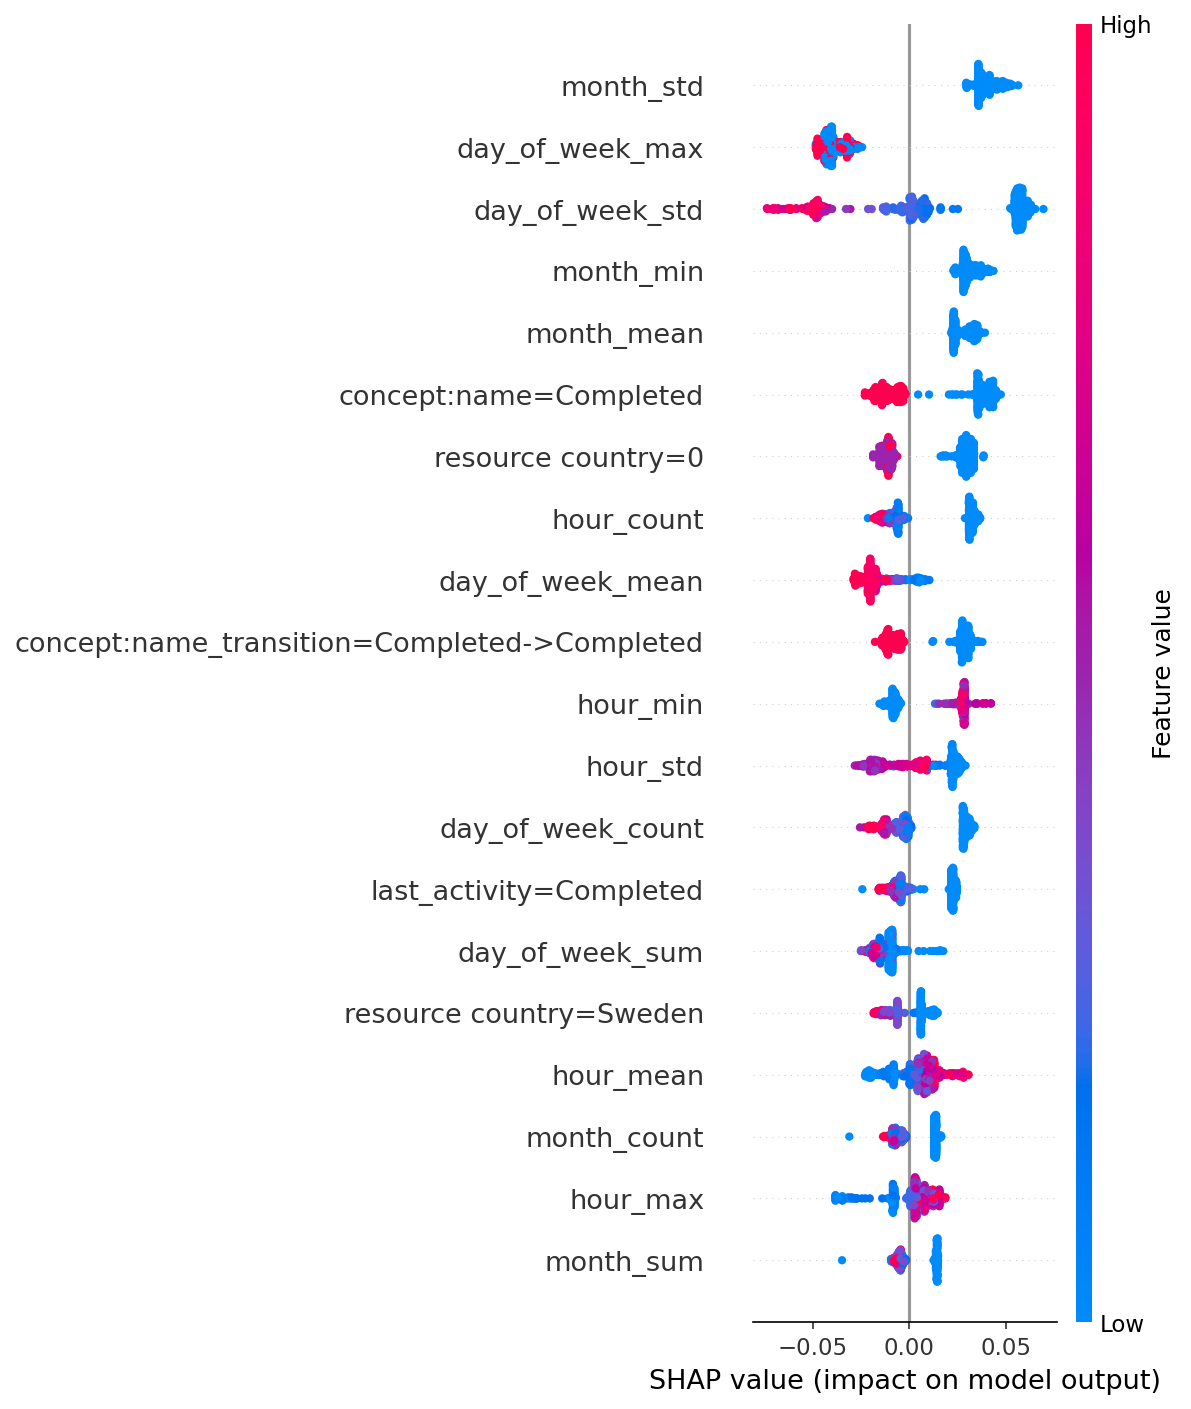

PosixPath('/Users/so/Desktop/explainable-process-prediction/figures/explanations/shap_summary_sprint2.png')

In [6]:
global_shap_path = save_global_shap_summary(
    model = shap_model,
    X=shap_X,
    feature_columns=shap_feature_columns,
    output_path= project_root / "figures" / "explanations" / "shap_summary_sprint2.png",
    max_samples=500,
)

display(Image(filename=str(global_shap_path)))
global_shap_path

## Global feature importance table

In [7]:
shap_importance_table = save_global_shap_importance_table(
    model=shap_model,
    X=shap_X,
    feature_columns=shap_feature_columns,
    output_path= project_root / "reports" / "shap_feature_importance_sprint2.csv",
    max_samples=500,
)

shap_importance_table.head(15)

,feature,mean_abs_shap
114,month_std,0.041097
101,day_of_week_max,0.039110
102,day_of_week_std,0.037303
112,month_min,0.031643
111,month_mean,0.028888
78,concept:name=Completed,0.023070
0,resource country=0,0.019678
97,hour_count,0.018255
99,day_of_week_mean,0.017795
85,concept:name_transition=Completed->Completed,0.017679


## Local SHAP explanations

In [8]:
local_shap_paths = save_selected_local_explanations(

    model=shap_model,

    X=shap_X,

    feature_columns=shap_feature_columns,

    y_true=shap_y_true,

    y_pred=shap_y_pred,

    output_dir=project_root / "figures" / "explanations",

)

local_shap_paths

{'correct_positive': PosixPath('/Users/so/Desktop/explainable-process-prediction/figures/explanations/shap_local_correct_positive.png'),
 'correct_negative': PosixPath('/Users/so/Desktop/explainable-process-prediction/figures/explanations/shap_local_correct_negative.png'),
 'misclassified': PosixPath('/Users/so/Desktop/explainable-process-prediction/figures/explanations/shap_local_misclassified.png')}

correct_positive


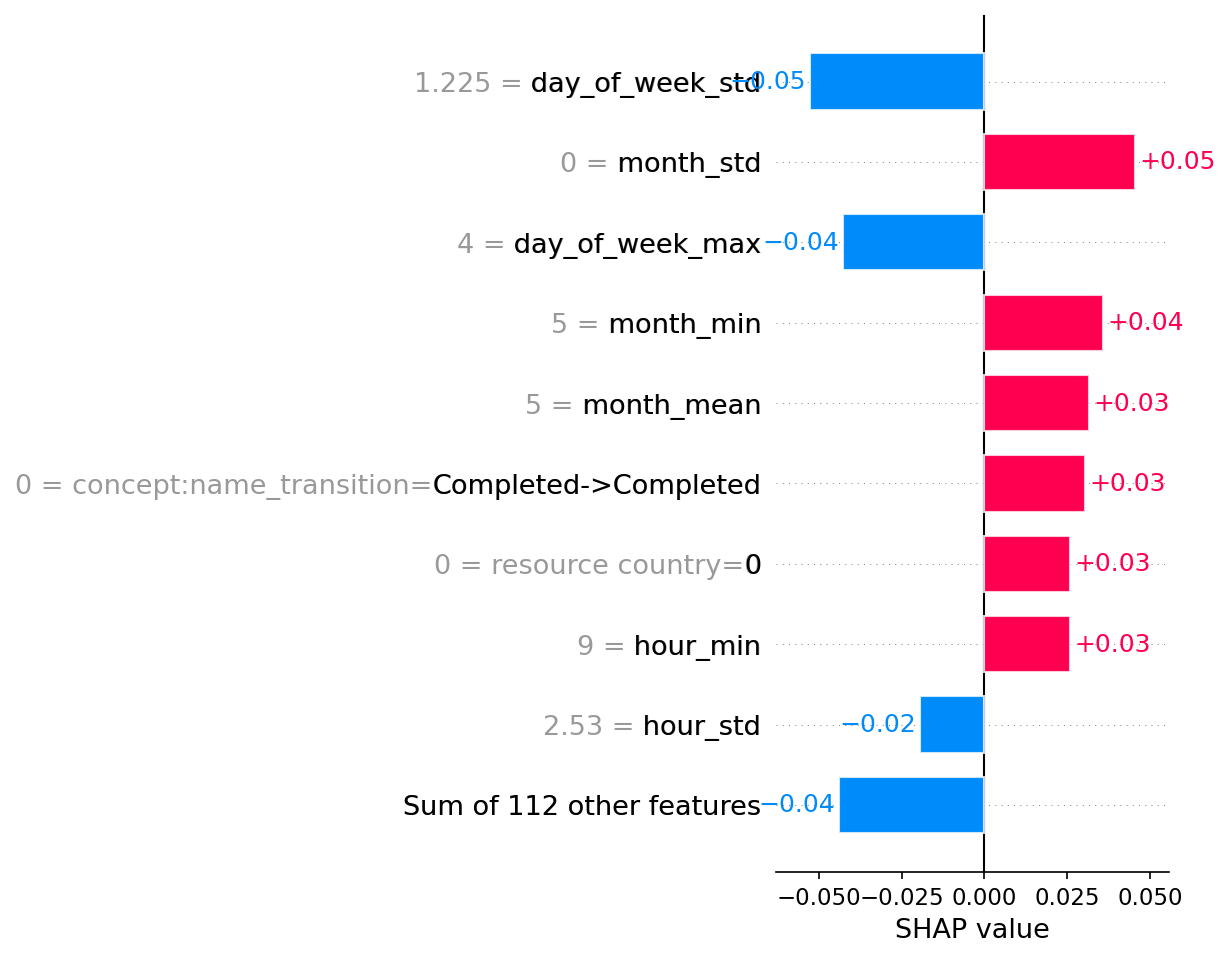

correct_negative


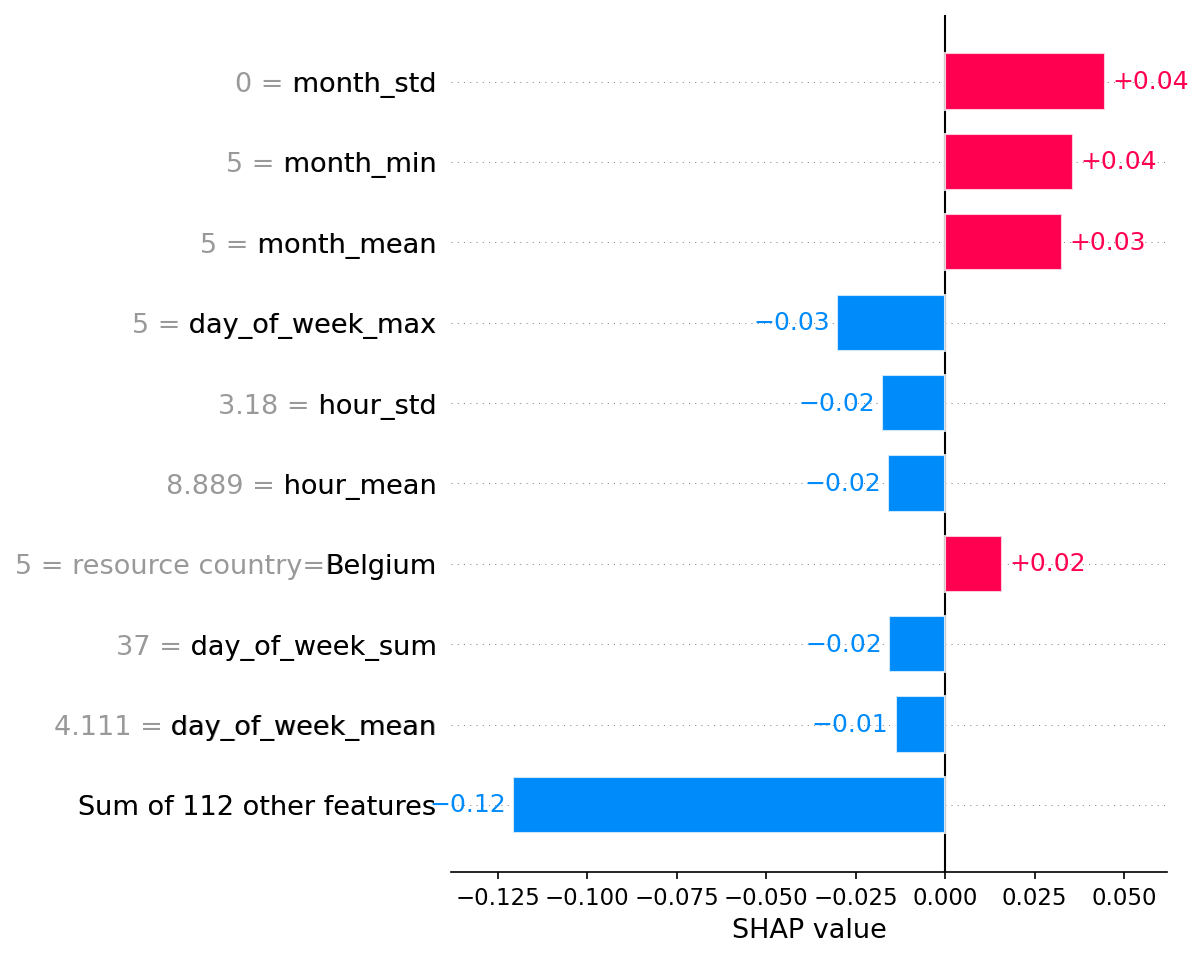

misclassified


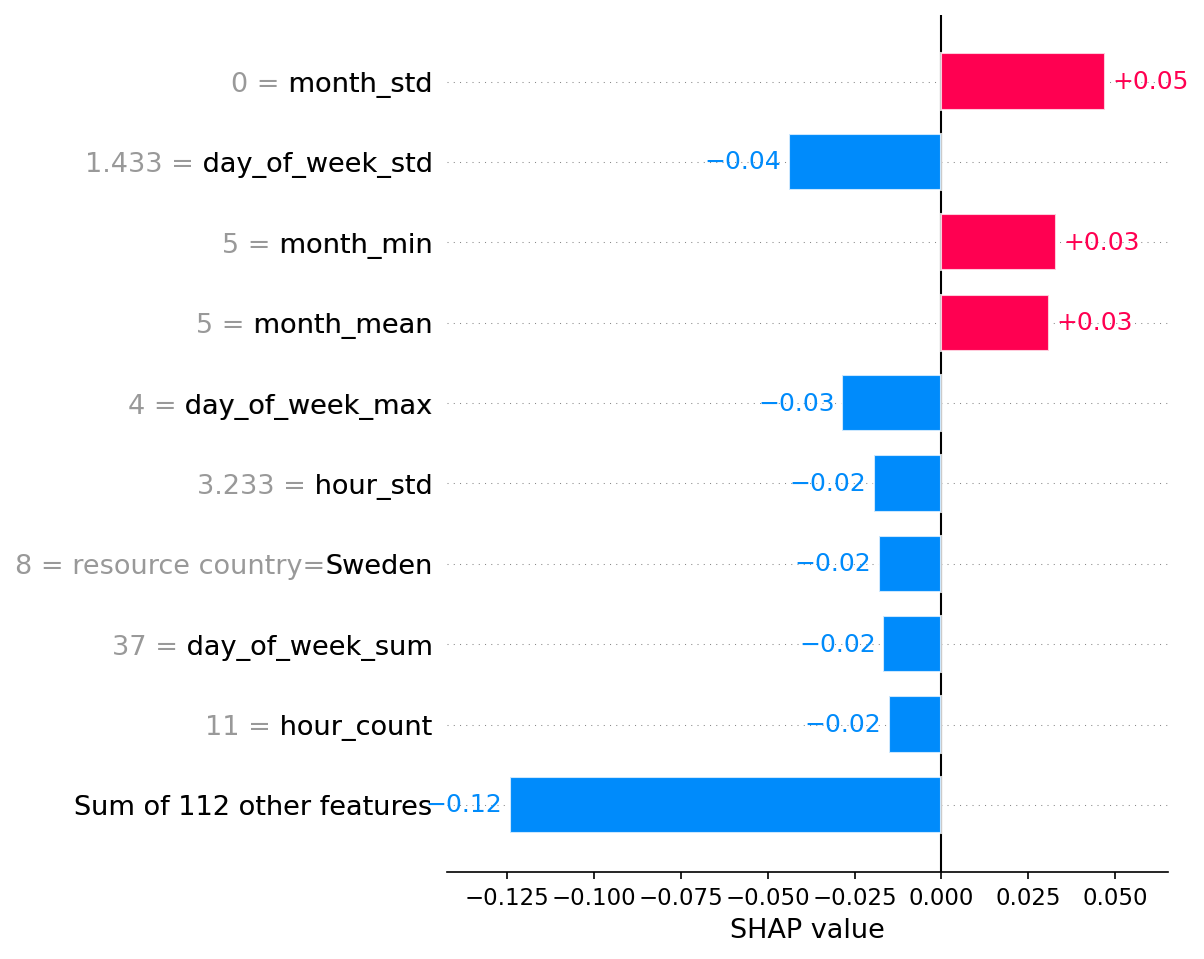

In [9]:
for case_type, path in local_shap_paths.items():
    print(case_type)
    display(Image(filename=str(path)))